# Sensor Correlation Analysis

## Objective

The objective of this notebook is to analyze the relationships between sensor measurements.

Highly correlated sensors often contain redundant information, while weakly correlated sensors may provide complementary information.

This notebook answers the following questions:

- Which sensors are strongly correlated?
- Are there groups of sensors measuring similar engine behavior?
- Which sensors may be redundant?
- Should any sensors be considered for removal based on correlation?

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH,
)

In [5]:
loader = DataLoader(
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-07-21 12:17:29 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-21 12:17:31 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-21 12:17:31 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-21 12:17:32 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-21 12:17:32 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-21 12:17:32 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully
2026-07-21 12:17:32 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-21 12:17:32 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-21 12:17:32 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

### Correlation Between Sensors

In [6]:
sensor_columns = [
    c
    for c in train_df.columns
    if c.startswith("sensor")
]

In [7]:
corr_matrix = train_df[sensor_columns].corr()

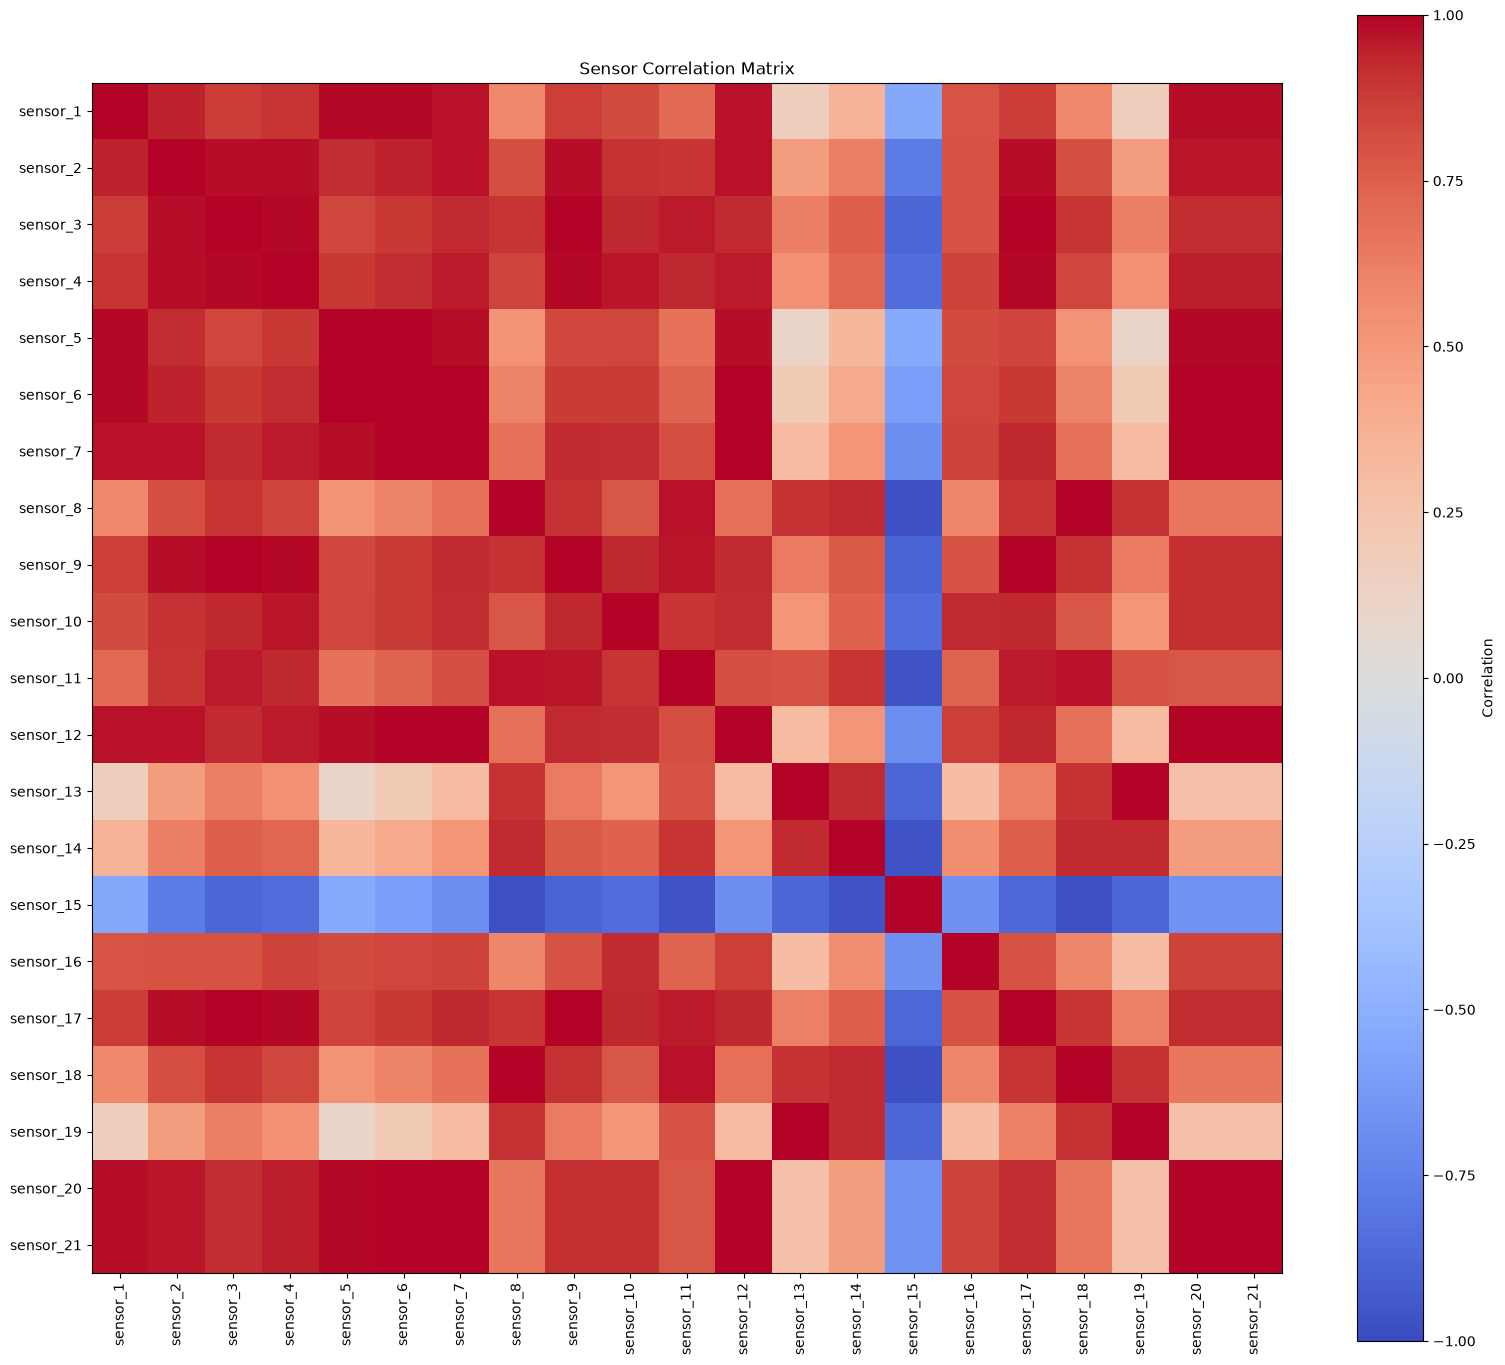

In [8]:
plt.figure(figsize=(16, 14))

plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(sensor_columns)),
    sensor_columns,
    rotation=90
)

plt.yticks(
    range(len(sensor_columns)),
    sensor_columns
)

plt.title("Sensor Correlation Matrix")

plt.tight_layout()

plt.show()

### Find Highly Correlated Sensor Pairs

Instead of manually reading the heatmap.

In [9]:
high_corr = []

threshold = 0.90

for i in range(len(sensor_columns)):
    for j in range(i + 1, len(sensor_columns)):

        corr = corr_matrix.iloc[i, j]

        if abs(corr) >= threshold:

            high_corr.append(
                (
                    sensor_columns[i],
                    sensor_columns[j],
                    corr
                )
            )

high_corr_df = (
    pd.DataFrame(
        high_corr,
        columns=[
            "Sensor A",
            "Sensor B",
            "Correlation"
        ]
    )
    .sort_values(
        "Correlation",
        ascending=False
    )
)

high_corr_df

,Sensor A,Sensor B,Correlation
56,sensor_8,sensor_18,0.999999
78,sensor_13,sensor_19,0.999998
47,sensor_7,sensor_12,0.999993
86,sensor_20,sensor_21,0.999897
49,sensor_7,sensor_20,0.999142
...,...,...,...
57,sensor_8,sensor_19,0.902625
79,sensor_14,sensor_15,-0.962958
70,sensor_11,sensor_15,-0.963709
82,sensor_15,sensor_18,-0.968752


### Count Connections

Which sensors are redundant with many others?

In [10]:
connection_count = {}

for sensor in sensor_columns:

    connection_count[sensor] = (
        (
            corr_matrix[sensor].abs() > threshold
        ).sum() - 1
    )

pd.Series(connection_count).sort_values(
    ascending=False
)

sensor_2     12
sensor_20    12
sensor_12    12
sensor_9     12
sensor_7     12
sensor_21    12
sensor_4     11
sensor_3     10
sensor_17    10
sensor_10    10
sensor_6      8
sensor_5      7
sensor_1      7
sensor_8      7
sensor_11     7
sensor_18     7
sensor_14     5
sensor_13     4
sensor_15     4
sensor_19     4
sensor_16     1
dtype: int64

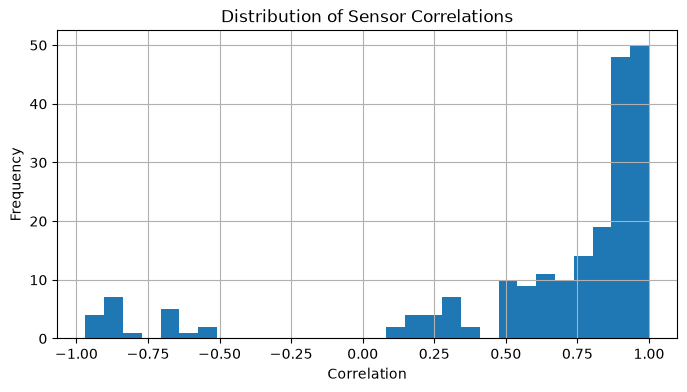

In [11]:
corr_values = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_values = corr_values.stack()

plt.figure(figsize=(8,4))

plt.hist(
    corr_values,
    bins=30
)

plt.title("Distribution of Sensor Correlations")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [12]:
import os
print(os.getcwd())

a:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL\notebooks


In [13]:
high_corr_df.to_csv(
    "../reports/highly_correlated_sensors.csv",
    index=False
)

# Observations

## Overall Correlation Structure

The correlation analysis reveals that many sensors are highly correlated with one another.

This suggests that multiple sensors are capturing similar aspects of engine behavior rather than providing entirely independent information.

---

## Highly Connected Sensors

The following sensors exhibit the largest number of strong correlations (|r| ≥ 0.90):

| Sensor | Number of Strong Correlations |
|---------|------------------------------:|
| Sensor 2 | 12 |
| Sensor 7 | 12 |
| Sensor 9 | 12 |
| Sensor 12 | 12 |
| Sensor 20 | 12 |
| Sensor 21 | 12 |

These sensors appear to belong to a strongly connected group of measurements.

---

## Moderately Connected Sensors

Several sensors show moderate connectivity, including:

- Sensor 3
- Sensor 4
- Sensor 10
- Sensor 17

These sensors may share information with some, but not all, of the remaining sensors.

---

## Weakly Connected Sensors

A few sensors exhibit relatively few strong correlations.

Examples include:

- Sensor 13
- Sensor 14
- Sensor 15
- Sensor 16
- Sensor 19

These sensors may capture more unique characteristics of engine operation.

---

## Sensor 16

Sensor 16 has only one strong correlation with another sensor.

Combined with previous EDA results, this suggests that Sensor 16 behaves differently from most other measurements.

Although it exhibited very low variance, its uniqueness indicates that it should not be removed without further investigation.

---

## Interpretation

The presence of several highly connected sensors indicates substantial redundancy within the feature space.

However, correlation alone does not determine feature usefulness.

Highly correlated sensors may still differ in predictive importance or robustness under varying operating conditions.

# Engineering Decisions

## Decision 1 — Preserve All Sensors

No sensors will be removed based solely on correlation.

Although several groups of highly correlated sensors exist, additional evidence is required before eliminating redundant features.

---

## Decision 2 — Document Redundant Sensor Groups

Sensors with many strong correlations (e.g., Sensors 2, 7, 9, 12, 20, and 21) will be documented as potential redundant feature groups.

These groups will be revisited during feature selection.

---

## Decision 3 — Preserve Weakly Connected Sensors

Sensors with few correlations (e.g., Sensor 16, Sensor 13, and Sensor 19) will be retained because they may contribute unique information not captured by other measurements.

---

## Decision 4 — Delay Feature Elimination

Final feature selection will combine evidence from:

- Variance analysis
- Lifecycle analysis
- Correlation analysis
- Model-based feature importance
- SHAP explainability

before removing any features.

---

## Decision 5 — Prepare for Feature Engineering

The observed correlation structure suggests that future feature engineering techniques (e.g., dimensionality reduction or model-based feature selection) may improve model efficiency while preserving predictive performance.